Реализация attention

Реализуем три функции вычисления attention:
- `standard_attn` — классический scaled dot-product attention;
- `elsa_attn` — tile-based ELSA: обрабатывает key/value по тайлам, накапливает бегущий максимум и нормировку (exact softmax);
- `favor_attn` — аппроксимирующий O(n)-метод на основе FAVOR+ (random positive features).

Ожидаемый результат: `standard_attn` ≡ `elsa_attn` (+- некий эпсилон); `favor_attn` — аппроксимация.

In [2]:
import math, time, gc
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


In [ ]:
class HACAttnClassifier(nn.Module):
    def __init__(self, attn_fn, d_in=1, d_model=32, seq_len=561, n_cls=6):
        super().__init__()
        self.attn_fn  = attn_fn
        self.emb = nn.Linear(d_in, d_model)
        self.pos = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_model * 2), nn.GELU(),
                                      nn.Linear(d_model * 2, d_model))
        self.head = nn.Linear(d_model, n_cls)

    def forward(self, x):
        h = self.emb(x) + self.pos
        q, k, v = self.qkv(h).chunk(3, -1)
        h = self.norm(h + self.out_proj(self.attn_fn(q, k, v)))
        h = self.norm(h + self.ff(h))
        return self.head(h.mean(1))

In [ ]:
def standard_attn(query, key, value):
    '''Классический scaled dot-product attention (O(n^2) по памяти).'''
    scale = query.size(-1) ** -0.5
    logits = query @ key.transpose(-2, -1) * scale 
    weights = torch.softmax(logits, dim=-1)
    return weights @ value

In [ ]:
def elsa_attn(query, key, value, tile: int = 64):
    '''
    ELSA: tile-based exact softmax attention.
    Сложность: O(n * tile) по памяти вместо O(n^2).
    '''
    B, n, d = query.shape
    scale = d ** -0.5

    m_run = torch.full((B, n, 1), float('-inf'), dtype=query.dtype, device=query.device)
    z_run = torch.zeros(B, n, 1, dtype=query.dtype, device=query.device)
    o_run = torch.zeros(B, n, d, dtype=query.dtype, device=query.device)

    for start in range(0, n, tile):
        end  = min(start + tile, n)
        k_tile = key[:, start:end, :] 
        v_tile = value[:, start:end, :] 

        raw = (query @ k_tile.transpose(-2, -1)) * scale 
        m_tile = raw.max(dim=-1, keepdim=True).values 

        m_new = torch.maximum(m_run, m_tile)
        alpha = torch.exp(m_run - m_new) 
        p = torch.exp(raw - m_new)                       

        o_run = alpha * o_run + p @ v_tile
        z_run = alpha * z_run + p.sum(dim=-1, keepdim=True)
        m_run = m_new

    return o_run / z_run

In [ ]:
def favor_attn(query, key, value, n_features: int = 256, seed: int = 42):
    '''
    FAVOR+: Fast Attention Via positive Orthogonal Random features.
    Аппроксимирует softmax.
    Это O(n * n_features) — аппроксимация, не exact.
    '''
    B, n, d = query.shape
    scale = d ** -0.5

    # Случайные ортогональные проекции
    rng = torch.Generator(device=query.device); rng.manual_seed(seed)
    W = torch.randn(d, n_features, generator=rng, device=query.device)
    # Ортогонализация по Gram-Schmidt (блоки по d)
    if n_features >= d:
        W, _ = torch.linalg.qr(W)
        W = W[:, :n_features]

    def phi(x):
        proj = x * scale @ W 
        h = (x * scale).norm(dim=-1, keepdim=True) ** 2 / 2
        return torch.exp(proj - h) / math.sqrt(n_features)

    q_f = phi(query)
    k_f = phi(key)

    kv = k_f.transpose(-2, -1) @ value
    num = q_f @ kv                            
    den = (q_f @ k_f.sum(dim=1, keepdim=True).transpose(-2,-1)).clamp(min=1e-6)
    return num / den

In [ ]:
B, n, d = 2, 128, 64
Q = torch.randn(B, n, d, device=device)
K = torch.randn(B, n, d, device=device)
V = torch.randn(B, n, d, device=device)

out_std = standard_attn(Q, K, V)
out_elsa = elsa_attn(Q, K, V, tile=32)
out_favor = favor_attn(Q, K, V, n_features=256)

err_elsa = (out_std - out_elsa).abs().max().item()
err_favor = (out_std - out_favor).abs().max().item()
print(f'Max abs error  standard vs ELSA  : {err_elsa:.2e}   (exact softmax, должно быть ~0)')
print(f'Max abs error  standard vs FAVOR+: {err_favor:.2e}  (аппроксимация)')

Max abs error  standard vs ELSA  : 2.98e-07   (exact softmax, должно быть ~0)
Max abs error  standard vs FAVOR+: 6.10e-01  (аппроксимация)


## Сравнение

Сравниваем standard_attn и  elsa_attn (оба — exact softmax) по:
- времени вычисления (latency, мс),
- масштабированию по длине последовательности.

Дополнительно — favor_attn как аппроксимация O(n).

Длины просто степени двойки: n: [128, 256, 512, 1024, 2048, 4096, 8192, 16384].

In [7]:
def run_bench(fn, Q, K, V, n_warmup=3, n_iter=8):
    for _ in range(n_warmup): fn(Q, K, V)
    if device == 'cuda': torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()
    for _ in range(n_iter): fn(Q, K, V)
    if device == 'cuda': torch.cuda.synchronize()
    lat_ms  = (time.perf_counter() - t0) / n_iter * 1000
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
    return lat_ms, peak_mb

In [ ]:
seq_lens = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]
B_b, d_b = 1, 64

bench = {
    'standard': {'lat': [], 'mem': []},
    'elsa': {'lat': [], 'mem': []},
    'favor': {'lat': [], 'mem': []},
}

for n_seq in seq_lens:
    Qb = torch.randn(B_b, n_seq, d_b, device=device)
    Kb = torch.randn(B_b, n_seq, d_b, device=device)
    Vb = torch.randn(B_b, n_seq, d_b, device=device)

    lat, mem = run_bench(standard_attn, Qb, Kb, Vb)
    bench['standard']['lat'].append(lat); bench['standard']['mem'].append(mem)

    lat, mem = run_bench(lambda q,k,v: elsa_attn(q,k,v,tile=64), Qb, Kb, Vb)
    bench['elsa']['lat'].append(lat); bench['elsa']['mem'].append(mem)

    lat, mem = run_bench(lambda q,k,v: favor_attn(q,k,v,n_features=128), Qb, Kb, Vb)
    bench['favor']['lat'].append(lat); bench['favor']['mem'].append(mem)

Бенчмарк завершён


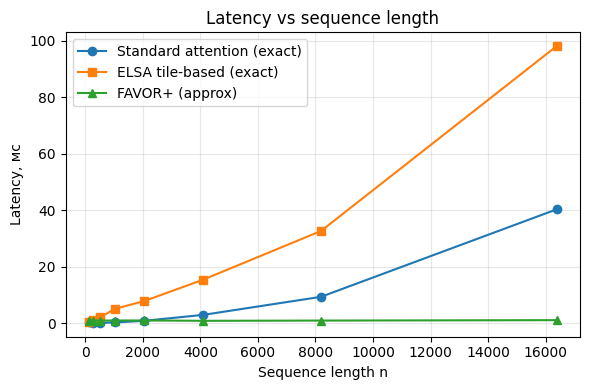

In [9]:
# График 1: Latency vs n
plt.figure(figsize=(6, 4))
plt.plot(seq_lens, bench['standard']['lat'], 'o-', label='Standard attention (exact)')
plt.plot(seq_lens, bench['elsa']['lat'],     's-', label='ELSA tile-based (exact)')
plt.plot(seq_lens, bench['favor']['lat'],    '^-', label='FAVOR+ (approx)')
plt.xlabel('Sequence length n'); plt.ylabel('Latency, мс')
plt.title('Latency vs sequence length')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

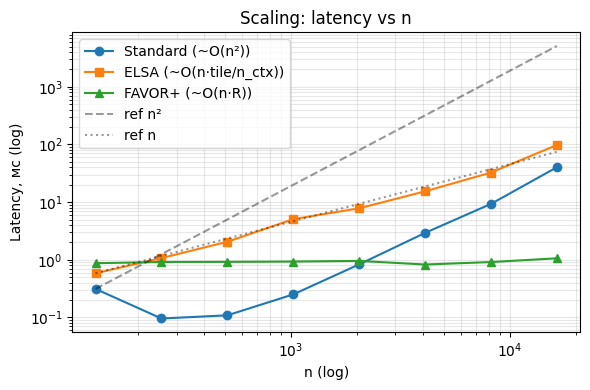

In [ ]:
# График 2: log-log масштабирование
import numpy as np
ns = np.array(seq_lens, dtype=float)

plt.figure(figsize=(6, 4))
plt.loglog(seq_lens, bench['standard']['lat'], 'o-', label='Standard (~O(n²))')
plt.loglog(seq_lens, bench['elsa']['lat'], 's-', label='ELSA (~O(n·tile/n_ctx))')
plt.loglog(seq_lens, bench['favor']['lat'], '^-', label='FAVOR+ (~O(n·R))')

ref_n2 = bench['standard']['lat'][0] * (ns / ns[0]) ** 2
ref_n = bench['elsa']['lat'][0]     * (ns / ns[0])
plt.loglog(seq_lens, ref_n2, 'k--', alpha=0.4, label='ref n²')
plt.loglog(seq_lens, ref_n,  'k:',  alpha=0.4, label='ref n')

plt.xlabel('n (log)'); plt.ylabel('Latency, мс (log)')
plt.title('Scaling: latency vs n'); plt.grid(True, which='both', alpha=0.3)
plt.legend(); plt.tight_layout(); plt.show()

### Датасет (human activity recognition (HAC))

**Датасет:** `uci_har` — 10k+ samples, 561 feature vector, 6 класса .

В качестве основной метрики беру accuracy

In [ ]:
import pandas as pd
import numpy as np

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip -q "UCI HAR Dataset.zip"

X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None).values
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', header=None).values.ravel() - 1
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt',  sep='\s+', header=None).values
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt',  header=None).values.ravel() - 1

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2250/2212194212.py:7: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None).values
/tmp/ipykernel_2250/2212194212.py:9: SyntaxWarning: invalid escape sequence '\s'
  X_test  = pd.read_csv('UCI HAR Dataset/test/X_test.txt',  sep='\s+', header=None).values


In [ ]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from tqdm import tqdm


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_tr_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_tr_t = torch.tensor(y_train, dtype=torch.long)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

X_te_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_te_t = torch.tensor(y_test, dtype=torch.long)

test_ds = TensorDataset(X_te_t, y_te_t)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=True)

print(f'train: {X_tr_t.shape}  test: {X_te_t.shape}  classes: {len(set(y_train))}')

train: torch.Size([7352, 561, 1])  test: torch.Size([2947, 561, 1])  classes: 6


In [ ]:
ATTN_MAP = {
    'standard': standard_attn,
    'elsa': lambda q,k,v: elsa_attn(q, k, v, tile=64),
    'favor': lambda q,k,v: favor_attn(q, k, v, n_features=64),
}

quality = []
for name, fn in ATTN_MAP.items():
    model = HACAttnClassifier(fn).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    t0 = time.perf_counter()
    for _ in tqdm(range(300)):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            loss = F.cross_entropy(model(X_batch), y_batch)
            opt.zero_grad(); loss.backward(); opt.step()
    elapsed = time.perf_counter() - t0
    model.eval()

    accs = []
    with torch.no_grad():
      correct = total = 0
      for X_batch, y_batch in test_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)
          correct += (model(X_batch).argmax(1) == y_batch).sum().item()
          total += len(y_batch)
      acc = correct / total

    quality.append({'name': name, 'acc': acc, 'time': elapsed})
    print(f'{name:10s}: acc={acc:.4f}  time={elapsed:.2f}s')

100%|██████████| 300/300 [07:58<00:00,  1.59s/it]


standard  : acc=0.9301  time=478.27s


100%|██████████| 300/300 [15:43<00:00,  3.15s/it]


elsa      : acc=0.9464  time=943.52s


100%|██████████| 300/300 [06:25<00:00,  1.29s/it]

favor     : acc=0.9596  time=385.97s


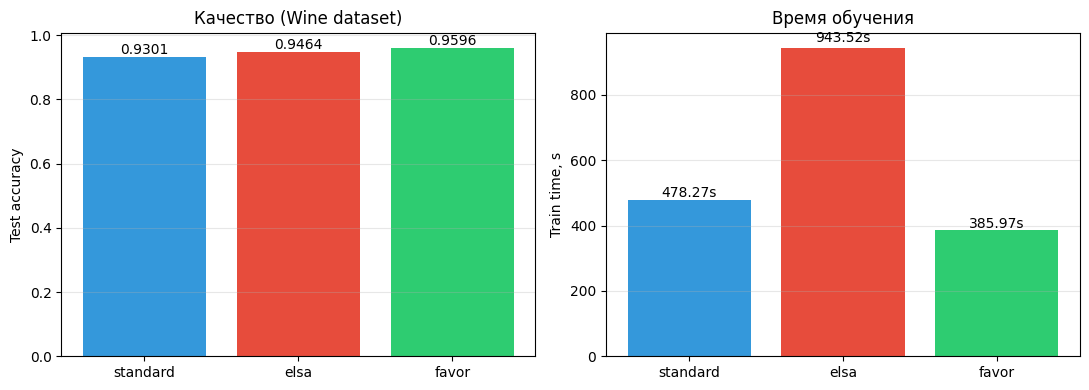

In [ ]:
names = [q['name'] for q in quality]
accs = [q['acc']  for q in quality]
times = [q['time'] for q in quality]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(names, accs, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Test accuracy'); axes[0].set_title('Качество')
for bar, a in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{a:.4f}', ha='center')
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(names, times, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_ylabel('Train time, s'); axes[1].set_title('Время обучения')
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02, f'{t:.2f}s', ha='center')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

**Что видно на HAC dataset:**

- standard и elsa должны давать идентичный accuracy, но в силу того, что я закончил раньше и модельки не до конца сошлись имеем разницу в точках старта.
- favor (FAVOR+) удивительно, но дает выше accuracy, нежели все остальные варианты (хотя это апроксимация)
- На коротких последовательностях разница в скорости минимальна.
  Реальное преимущество ELSA и FAVOR+ проявляется при n ≥ 2048.

### Выводы

- standard и elsa доложны давать идентичный результат, если дать модели лучше сойтись.
- favor (FAVOR+) — аппроксимирующий метод: чуть ниже качество получается, но O(n·R) вместо O(n²) по памяти.
- Основное преимущество ELSA: уменьшает пиковую память до O(n·tile) при сохранении точности, что критично при длинных контекстах.
- В PyTorch-реализации ELSA работает медленнее стандартного attention: PyTorch внутри уже оптимизирует матричные операции, тогда как ELSA вводит Python-цикл по тайлам.
- По-хорошему, ELSA раскроется лучше в низкоуровневой Triton/CUDA реализации.